## Heart Disease Prediction using ANN in TensorFlow

### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/50-Heart%20Disease%20Prediction/Dataset--Heart-Disease-Prediction-using-ANN.csv"

In [3]:
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(303, 14)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


2. Feature Selection

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [10]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

3. Train Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Feature Scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_trian = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### 4. Build the Model

In [14]:
import tensorflow as tf 

model = tf.keras.Sequential([
    tf.keras.layers.Dense(activation = "relu", input_dim = 13, units = 8, kernel_initializer = "uniform"),
    tf.keras.layers.Dense(activation = "relu", units = 14, kernel_initializer = "uniform"),
    tf.keras.layers.Dense(activation = "sigmoid", units = 1, kernel_initializer = "uniform"),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253 (1012.00 B)

 Trainable params: 253 (1012.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. Compile and Fit the Model

In [15]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'] 
    )

In [21]:
history = model.fit(
    X_train, y_train, 
    batch_size = 8,
    validation_data = (X_test[:30], y_test[:30]),
    epochs = 100 
 )

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4339 - loss: 0.6946 - val_accuracy: 0.5333 - val_loss: 0.6929
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5455 - loss: 0.6926 - val_accuracy: 0.5333 - val_loss: 0.6926
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5620 - loss: 0.6922 - val_accuracy: 0.5333 - val_loss: 0.6923
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5496 - loss: 0.6916 - val_accuracy: 0.5333 - val_loss: 0.6920
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5496 - loss: 0.6919 - val_accuracy: 0.5333 - val_loss: 0.6917
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5496 - loss: 0.6870 - val_accuracy: 0.5333 - val_loss: 0.6914
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5496 - loss: 0.6837 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6033 - loss: 0.6799 - val_accuracy: 0.5333 - 

### 6. Make Prediction

In [31]:
import pandas as pd

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

compare = pd.DataFrame({
    "Predicted": y_pred,
    "Actual": y_test
})

compare.head()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


,Predicted,Actual
0,0,0
1,0,0
2,0,1
3,0,0
4,1,1


### 7. Evaluate the Model

Accuracy: 0.6066

Classification Report:
              precision    recall  f1-score   support

           0       0.55      1.00      0.71        29
           1       1.00      0.25      0.40        32

    accuracy                           0.61        61
   macro avg       0.77      0.62      0.55        61
weighted avg       0.78      0.61      0.55        61



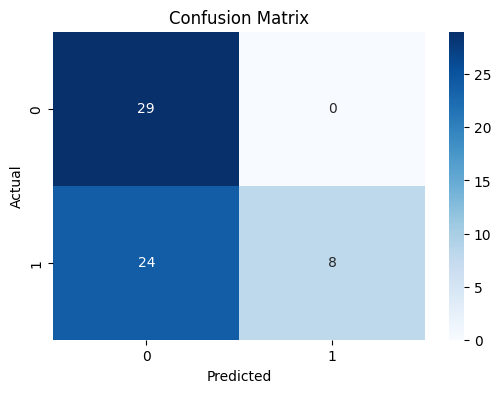

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# 1) Predict on test set
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = np.array(y_test).flatten()

# 2) Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# 3) Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# 4) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# 5) Put metrics into a dataframe
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [acc, prec, rec, f1]
})

print("\nMetrics Table:")
print(metrics_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Accuracy : 0.6066
Precision: 1.0000
Recall   : 0.2500
F1-score : 0.4000

Classification Report:

              precision    recall  f1-score   support

           0       0.55      1.00      0.71        29
           1       1.00      0.25      0.40        32

    accuracy                           0.61        61
   macro avg       0.77      0.62      0.55        61
weighted avg       0.78      0.61      0.55        61

Confusion Matrix:
 [[29  0]
 [24  8]]

Metrics Table:
      Metric     Value
0   Accuracy  0.606557
1  Precision  1.000000
2     Recall  0.250000
3   F1-score  0.400000


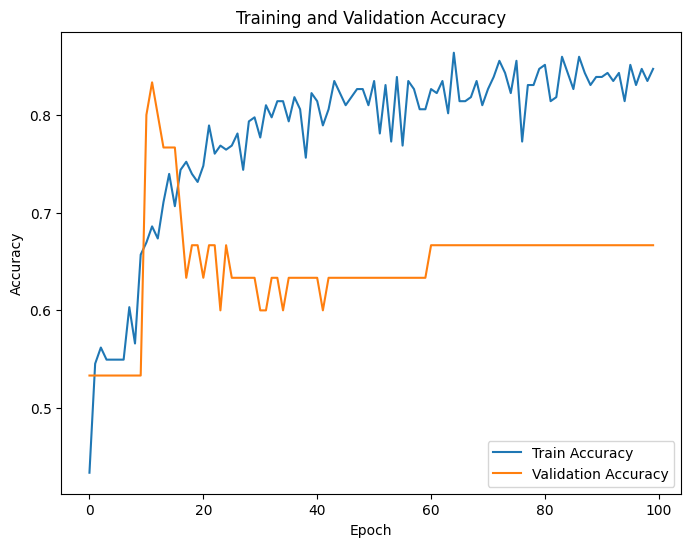

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

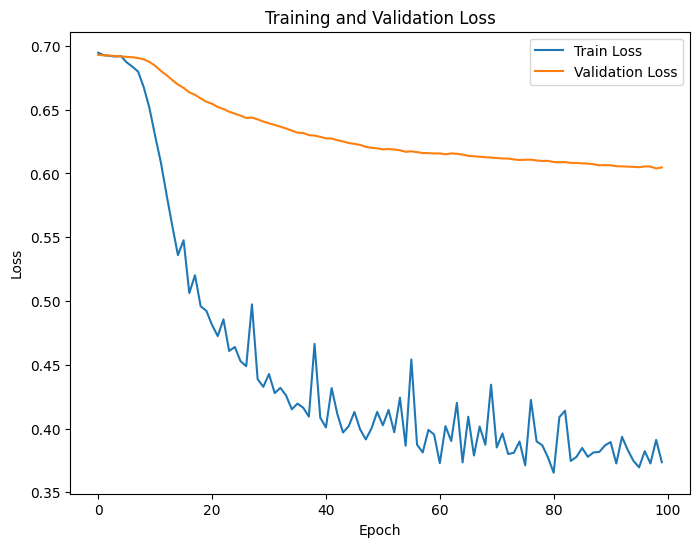

In [35]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

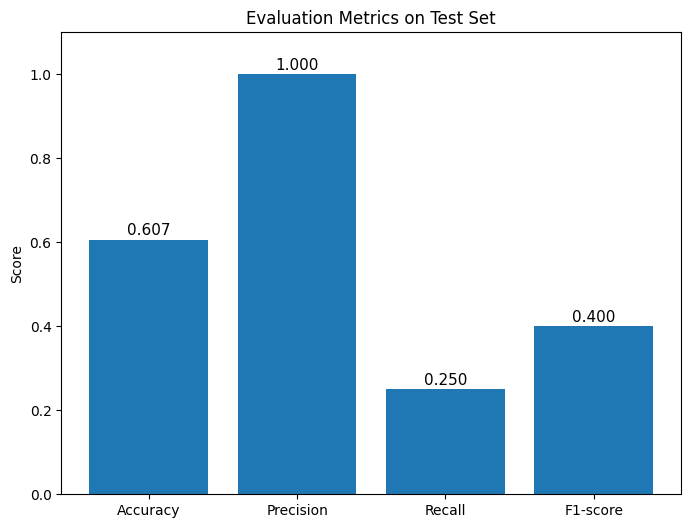

In [36]:
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics_df["Metric"], metrics_df["Value"])

for i, v in enumerate(metrics_df["Value"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11)

plt.title("Evaluation Metrics on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.show()

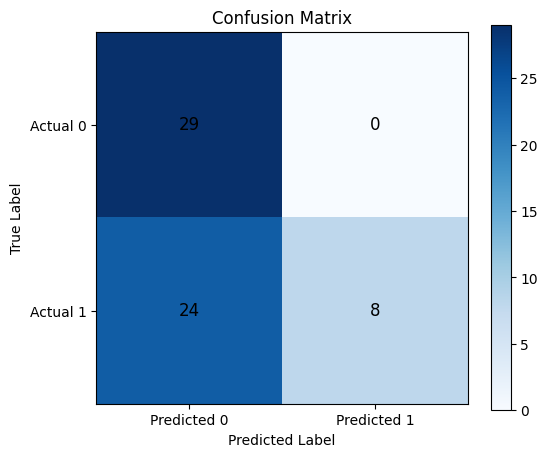

In [37]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

AUC: 0.8966


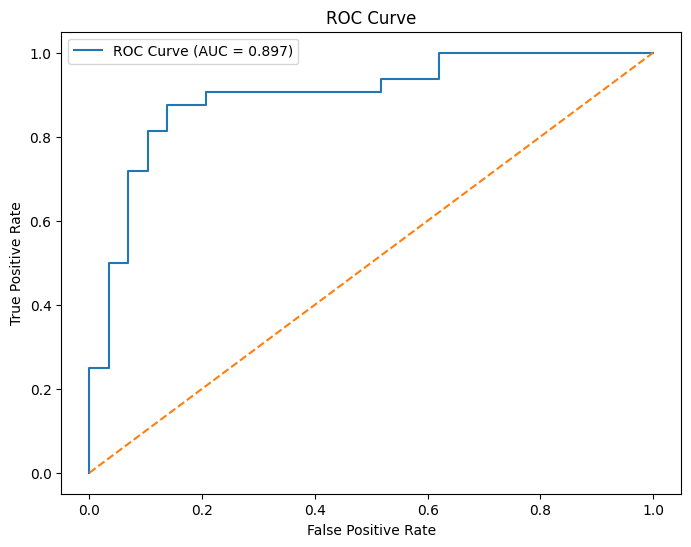

In [38]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob.flatten())
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [40]:
compare = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred,
    "Probability": y_prob.flatten()
})

compare.head(10)

,Actual,Predicted,Probability
0,0,0,0.274161
1,0,0,0.437154
2,1,0,0.441766
3,0,0,0.307835
4,1,1,0.556873
5,1,0,0.445997
6,1,0,0.383787
7,0,0,0.276275
8,0,0,0.220943
9,1,0,0.383662
